# **ML classification - category**

**index:**

1 SVM(support vecotor machine learning) classification

2 naive baynes, decision tree, random forest

3 k-means, hierarchical clustering

**description:**

SVM - classify data by adding 1 straight line.

naive baynes - use probability to predict result. Ex.spam filtering, document categorization, and sentiment analysis

decision tree - separate items by some group from data Ex.Loan Approval in Banking,Medical Diagnosis,Predicting Exam Results in Educatio,Customer Churn Prediction,Fraud Detection

categorise customer to group by income x spending score -

k-means - k-means find optimal number of cluster(i) with elbow mothod

hierarchical clustering - hierarchical find optimal number of cluster(i) with dendogram


**graph looks like:**

1 naive baynes
ex. find mail spam or not spam
y     B  
|     B B
|   A ?
|A AA  A
-----------x x=0,o=1 prediction:?=1 y=a+bx1+bx2²

2 category decision tree
ex.find income by level
y    xx  
|    xx
|xx     xx
|xx     xx
-----------x x=0,o=1 prediction:?=1 y=a+bx1+bx2²


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import math
import numpy as np
import pandas as pd
import statistics
import random
import json
import requests
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC,SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import cross_val_score
import scipy.cluster.hierarchy as sch
# from apyori import apriori
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
# import tensorflowjs as tfjs
sc=StandardScaler()#x=(x-μ)/σ μ:mean σ:stev
le=LabelEncoder()
f1_40=pd.read_csv('/content/drive/MyDrive/ml/asset/sales_age_income_40.csv')
f1_400=pd.read_csv('/content/drive/MyDrive/ml/asset/sales_age_income_400.csv')
f1_1554=pd.read_csv('/content/drive/MyDrive/ml/asset/sales_age_income_1554.csv')
f1_3_knn_1=pickle.load(open('/content/drive/MyDrive/ml/asset/knn_purchase_yn.pkl','rb'))
f1_3_knn_1=pickle.load(open('/content/drive/MyDrive/ml/asset/knn_purchase_yn_sc.pkl','rb'))
f1_3_h5=load_model('/content/drive/MyDrive/ml/asset/tf_purchase_yn.h5')
f2=pd.read_csv('/content/drive/MyDrive/ml/asset/salary_role.csv')
f3=pd.read_csv('/content/drive/MyDrive/ml/asset/salary_exp.csv')
f4=pd.read_csv('/content/drive/MyDrive/ml/asset/startups1.csv')
f5_1=pd.read_csv('/content/drive/MyDrive/ml/asset/customer1.csv')
f5_2=pd.read_csv('/content/drive/MyDrive/ml/asset/customer2.csv')
f6=pd.read_csv('/content/drive/MyDrive/ml/asset/grocery_list.csv')
f7=pd.read_csv('/content/drive/MyDrive/ml/asset/ad_clickrate.csv')
f8_1=pd.read_csv('/content/drive/MyDrive/ml/asset/wine1.csv')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


**1 SVC**

accuracy score 0.91
0-False 1-True
example1  age 30, salary 87KUSD:  [0]
example2  age 27, salary 137KUSD: [1]


/tmp/ipython-input-1740288887.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_f1_2_set[y_set == j, 0], x_f1_2_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


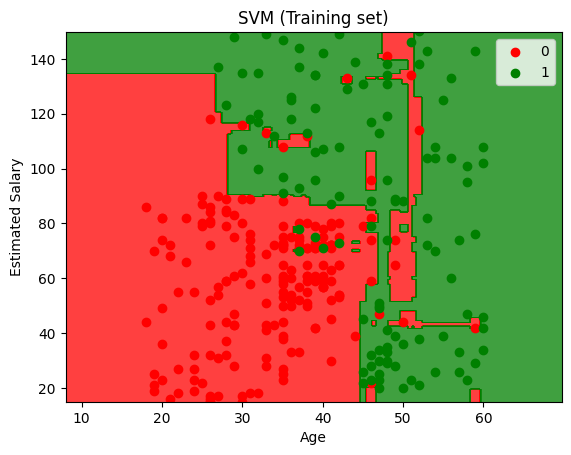

/tmp/ipython-input-1740288887.py:58: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


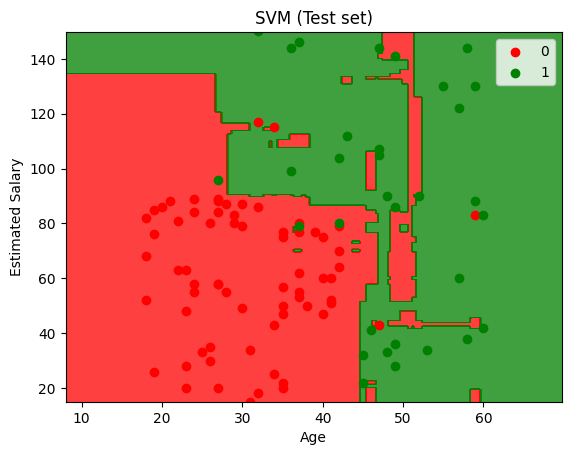

In [7]:
# 1 get dataset
x_f1_2=f1_400.iloc[:,:-1].values
y_f1_2=f1_400.iloc[:,-1].values
x_f1_2_80,x_f1_2_20,y_f1_2_80,y_f1_2_20=train_test_split(x_f1_2,y_f1_2,test_size=.25,random_state=0)
x_f1_2_80=sc.fit_transform(x_f1_2_80)#training: 80% of item
x_f1_2_20=sc.transform(x_f1_2_20)#test: 20% of item

x14=SVC(kernel='linear',random_state=0)#1 support vector machine linear classification
# x14=SVC(kernel='rbf', random_state=0)#2 support vector machine radial basis function classification
#x14=GaussianNB()#3 select this for naive baynes
#x14=DecisionTreeClassifier(criterion = 'entropy', random_state = 0)#4 select this for decision tree
x14=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)#select this for random forest
x14.fit(x_f1_2_80,y_f1_2_80)

# 2 find accuracy level
y_f1_2_pred=x14.predict(x_f1_2_20)
# print(confusion_matrix(y_f1_2_20, y_f1_2_pred))
# print(np.concatenate((y_f1_2_pred.reshape(len(y_f1_2_pred),1), y_f1_2_20.reshape(len(y_f1_2_20),1)),1))
print('accuracy score',accuracy_score(y_f1_2_20, y_f1_2_pred))
# svm linear 0.9 x.91
# svm rbf 0.93  x.91
# naive baynes     400items: .9
# decision tree    400items: .91
# random forest    400items: .91

# 3 predict
print('0-False 1-True')
# example1 age 30, salary 87KUSD
print('example1  age 30, salary 87KUSD: ',x14.predict(sc.transform([[30,87]])))
# example2 age 27, salary 137KUSD
print('example2  age 27, salary 137KUSD:',x14.predict(sc.transform([[27,137]])))

# 4.1 graph training
x_f1_2_set, y_set = sc.inverse_transform(x_f1_2_80), y_f1_2_80
X1, X2 = np.meshgrid(np.arange(start = x_f1_2_set[:, 0].min() - 10, stop = x_f1_2_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = x_f1_2_set[:, 1].min(), stop = x_f1_2_set[:, 1].max(), step = 0.25))
plt.contourf(X1, X2, x14.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_f1_2_set[y_set == j, 0], x_f1_2_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

# 4.2 graph test
x_f1_2_set, y_f1_2_set = sc.inverse_transform(x_f1_2_20), y_f1_2_20
X1, X2 = np.meshgrid(np.arange(start = x_f1_2_set[:, 0].min() - 10, stop = x_f1_2_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = x_f1_2_set[:, 1].min(), stop = x_f1_2_set[:, 1].max(), step = 0.25))
plt.contourf(X1, X2, x14.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_f1_2_set)):
    plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

**2 naive baynes, decision tree, random forest**

accuracy score 0.91
example1 age 27, salary 137KUSD  [1]


/tmp/ipython-input-1799435583.py:32: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


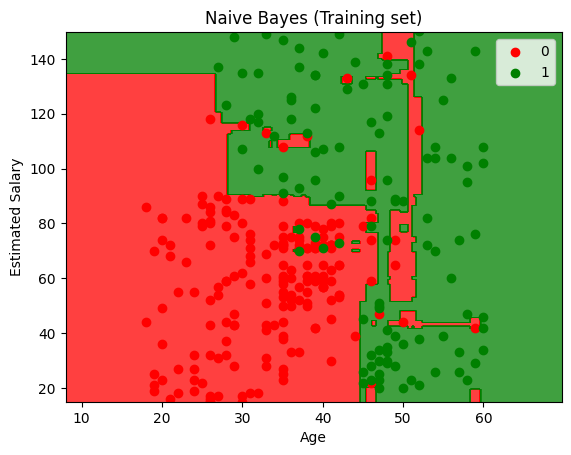

/tmp/ipython-input-1799435583.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


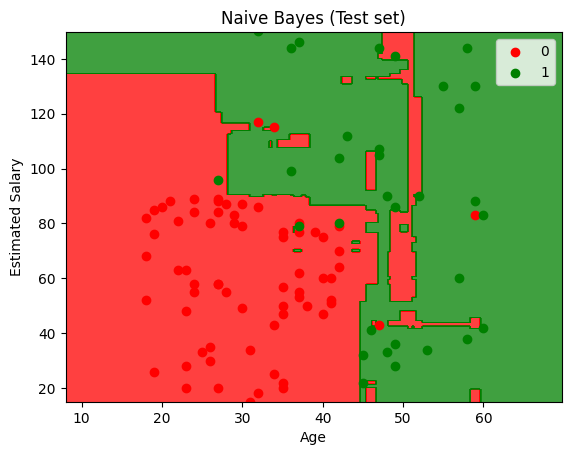

In [9]:
# 1 get dataset
x_f1_2=f1_400.iloc[:,:-1].values
y_f1_2=f1_400.iloc[:,-1].values
x_f1_2_80,x_f1_2_20,y_f1_2_80,y_f1_2_20=train_test_split(x_f1_2,y_f1_2,test_size=.25,random_state=0)
x_f1_2_80=sc.fit_transform(x_f1_2_80)#training: 80% of item
x_f1_2_20=sc.transform(x_f1_2_20)#test: 20% of item
# x15=GaussianNB()#select this for naive baynes
#x15=DecisionTreeClassifier(criterion = 'entropy', random_state = 0)#select this for decision tree
x15=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)#select this for random forest
x15.fit(x_f1_2_80,y_f1_2_80)
y_f1_2_pred=x15.predict(x_f1_2_20)
# print(np.concatenate((y_f1_2_pred.reshape(len(y_f1_2_pred),1), y_f1_2_20.reshape(len(y_f1_2_20),1)),1))
# print(confusion_matrix(y_f1_2_20, y_f1_2_pred))
print('accuracy score',accuracy_score(y_f1_2_20, y_f1_2_pred))#0.91
# naive baynes     400items: .9
# decision tree    400items: .91
# random forest    400items: .91

# 3 predict
# example1 age 27, salary 137KUSD
print('example1 age 27, salary 137KUSD ',x15.predict(sc.transform([[27,137]])))

# 4.1 graph training
x_f1_2_set, y_f1_2_set = sc.inverse_transform(x_f1_2_80),y_f1_2_80
X1, X2 = np.meshgrid(np.arange(start = x_f1_2_set[:, 0].min() - 10, stop = x_f1_2_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = x_f1_2_set[:, 1].min(), stop = x_f1_2_set[:, 1].max(), step = 0.25))
plt.contourf(X1, X2, x15.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_f1_2_set)):
    plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

# 4.2 graph test
x_f1_2_set, y_f1_2_set = sc.inverse_transform(x_f1_2_20),y_f1_2_20
X1, X2 = np.meshgrid(np.arange(start = x_f1_2_set[:, 0].min() - 10, stop = x_f1_2_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = x_f1_2_set[:, 1].min(), stop = x_f1_2_set[:, 1].max(), step = 0.25))
plt.contourf(X1, X2, x15.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_f1_2_set)):
    plt.scatter(x_f1_2_set[y_f1_2_set == j, 0], x_f1_2_set[y_f1_2_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

**3 k-means, hierarchical clustering**

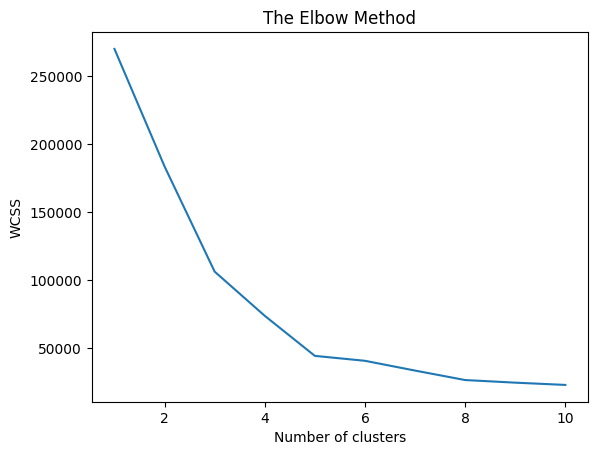

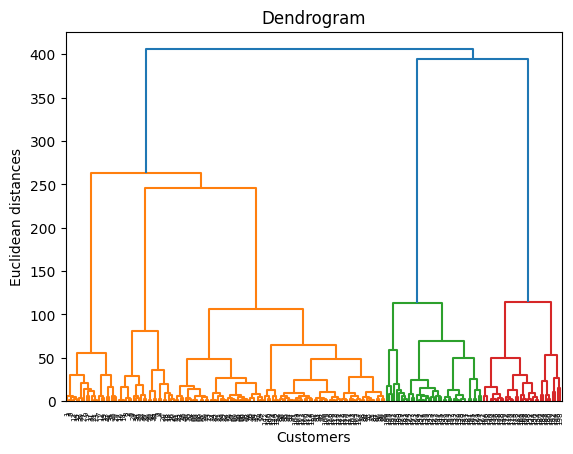

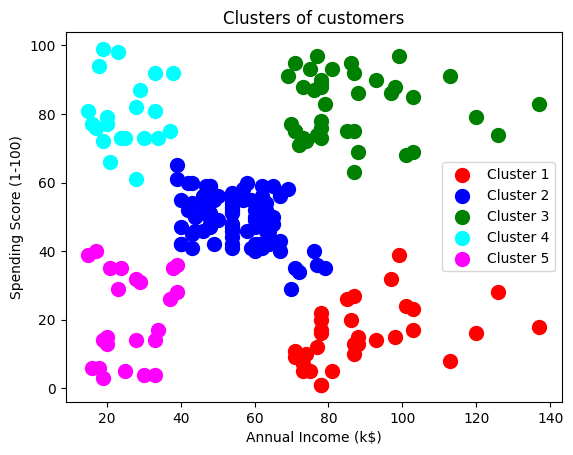

In [10]:
# 1 create dataset
x_f5_1 = f5_1.iloc[:,[3,4]].values #use only income&spending score
#--------------------
#x
# x
#  x
#   ixxxxxxx i=4
#123455678..
#--------------------
#2 k-means find optimal number of cluster(i) with elbow mothod
wcss=[]
for i in range(1,11):
    x=KMeans(n_clusters=i,init='k-means++',random_state=42)
    x.fit(x_f5_1)
    wcss.append(x.inertia_)
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#2 hierarchical find optimal number of cluster(i) with dendogram
dendrogram=sch.dendrogram(sch.linkage(x_f5_1,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

#3 add number you found from 1. to i.  n_clusters=i x:Annual Income y:Spending Score
#x17=KMeans(n_clusters=5,init='k-means++',random_state=42)# select this for kmeans
x17=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')# select this for hierarchical
y_f5_1_analyse=x17.fit_predict(x_f5_1)
# print(y_f5_1_analyse)

plt.scatter(x_f5_1[y_f5_1_analyse==0,0],x_f5_1[y_f5_1_analyse==0,1],s=100,c='red',label='Cluster 1')
plt.scatter(x_f5_1[y_f5_1_analyse==1,0],x_f5_1[y_f5_1_analyse==1,1],s=100,c='blue',label='Cluster 2')
plt.scatter(x_f5_1[y_f5_1_analyse==2,0],x_f5_1[y_f5_1_analyse==2,1],s=100,c='green',label='Cluster 3')
plt.scatter(x_f5_1[y_f5_1_analyse==3,0],x_f5_1[y_f5_1_analyse==3,1],s=100,c='cyan',label='Cluster 4')
plt.scatter(x_f5_1[y_f5_1_analyse==4,0],x_f5_1[y_f5_1_analyse==4,1],s=100,c='magenta',label='Cluster 5')
# plt.scatter(x17.cluster_centers_[:,0],x17.cluster_centers_[:,1],s=300,c='yellow',label='Centroids')# select this for kmeans
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Classify customer into some groups and send only VIP group(cluster3)